Pronostico de Cancelación de Clientes para Interconnect

Desarrollar un modelo de aprendizaje automático que prediga la tasa de cancelación de clientes de Interconnect, utilizando datos personales, de contrato, servicios de internet y telefonía. El modelo permitirá identificar clientes en riesgo de cancelar para ofrecerles promociones personalizadas.

In [45]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import category_encoders as ce
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.combine import SMOTETomek
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score
import joblib
plt.style.use('ggplot')
sns.set_palette('Set2')


# Carga de datos

In [46]:
contract = pd.read_csv('/datasets/contract.csv')
personal = pd.read_csv('/datasets/personal.csv')
internet = pd.read_csv('/datasets/internet.csv')
phone = pd.read_csv('/datasets/phone.csv')


# Análisis exploratorio de datos

In [47]:
# Resumen de los datos
def resumen(df, nombre):
    print(f"\n {nombre}")
    print("Forma:", df.shape)
    print("Duplicados:", df.duplicated().sum())
    print("Nulos:\n", df.isnull().sum())
    display(df.head())

resumen(contract, "contract.csv")
resumen(personal, "personal.csv")
resumen(internet, "internet.csv")
resumen(phone, "phone.csv")



 contract.csv
Forma: (7043, 8)
Duplicados: 0
Nulos:
 customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65



 personal.csv
Forma: (7043, 5)
Duplicados: 0
Nulos:
 customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



 internet.csv
Forma: (5517, 8)
Duplicados: 0
Nulos:
 customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



 phone.csv
Forma: (6361, 2)
Duplicados: 0
Nulos:
 customerID       0
MultipleLines    0
dtype: int64


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Los datos presentan una estructura limpia y confiable, lo que permite avanzar con seguridad hacia el preprocesamiento y modelado. La ausencia de nulos y duplicados garantiza que no se introduzcan sesgos ni errores por imputación.


In [48]:
# Unimos los datasets progresivamente
df = personal.merge(contract, on='customerID', how='inner')
df = df.merge(internet, on='customerID', how='inner')
df = df.merge(phone, on='customerID', how='inner')

# Verificamos la forma final
print(" Dataset unificado — forma:", df.shape)
display(df.head())


 Dataset unificado — forma: (4835, 20)


,customerID,gender,SeniorCitizen,Partner,Dependents,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,5575-GNVDE,Male,0,No,No,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,DSL,Yes,No,Yes,No,No,No,No
1,3668-QPYBK,Male,0,No,No,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,DSL,Yes,Yes,No,No,No,No,No
2,9237-HQITU,Female,0,No,No,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,No,No,No,No,No,No
3,9305-CDSKC,Female,0,No,No,2019-03-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,99.65,820.5,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
4,1452-KIOVK,Male,0,No,Yes,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,Fiber optic,No,Yes,No,No,Yes,No,Yes


La unificación permitió construir una vista completa y coherente de cada cliente, integrando variables clave para el análisis de cancelación. El tamaño final del dataset (4835 clientes).

               EndDate Churn
0                   No    No
1  2019-12-01 00:00:00   Yes
2  2019-11-01 00:00:00   Yes
3  2019-11-01 00:00:00   Yes
4                   No    No
Churn
No     3249
Yes    1586
Name: count, dtype: int64


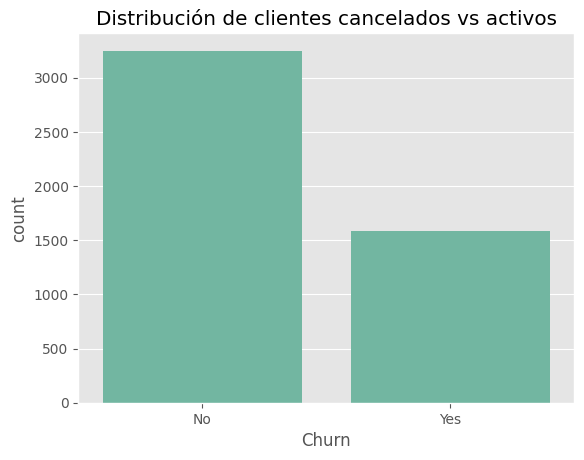

In [49]:
# Creamos la columna Churn basada en EndDate
df['Churn'] = df['EndDate'].apply(lambda x: 'No' if x == 'No' else 'Yes')
print(df[['EndDate', 'Churn']].head())
# Verificamos la distribución
print(df['Churn'].value_counts())
sns.countplot(data=df, x='Churn')
plt.title("Distribución de clientes cancelados vs activos")
plt.show()


Clientes activos tenemos 3249 y clientes que cancelaron 1586. Este nivel de churn justifica la implementación de un modelo predictivo que permita anticipar cancelaciones y aplicar acciones preventivas, como promociones personalizadas o mejoras en el servicio.


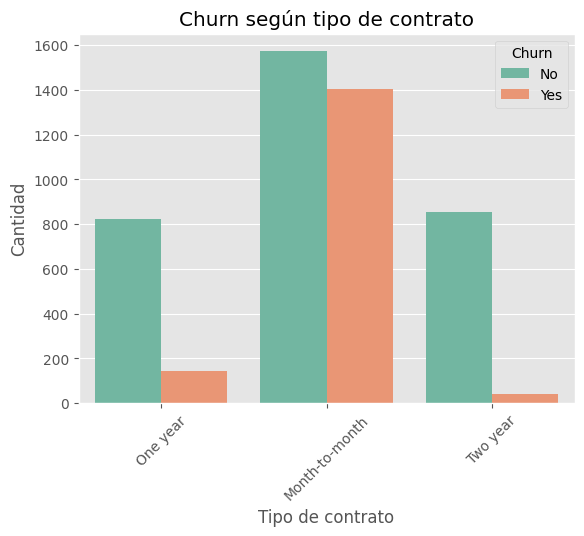

In [50]:
sns.countplot(data=df, x='Type', hue='Churn')
plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()


La duración del contrato es un factor determinante en la retención de clientes. Los contratos mensuales ofrecen mayor flexibilidad, pero también implican mayor riesgo de cancelación. En cambio, los contratos de largo plazo (uno y dos años) están asociados con mayor estabilidad y fidelización


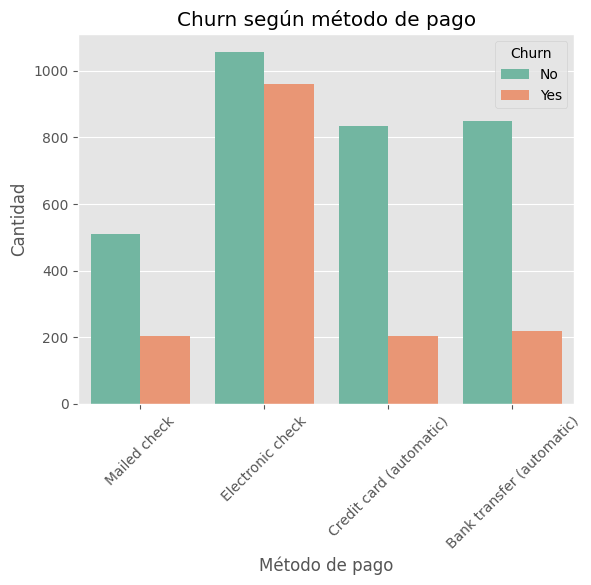

In [51]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()


Los pagos electrónicos no automáticos (como Electronic Check) podrían reflejar menor compromiso o menor fidelización, mientras que los pagos automáticos están vinculados a mayor permanencia.

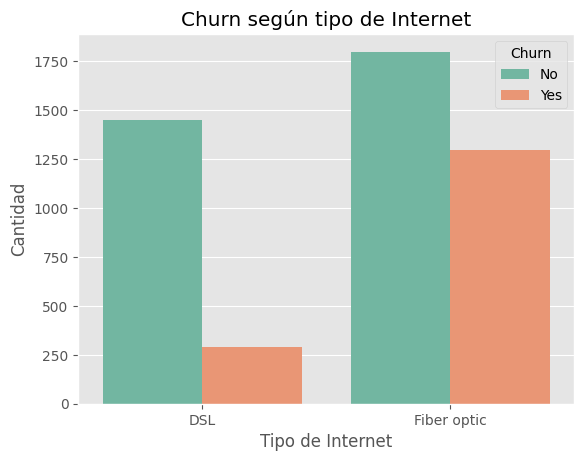

In [52]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn según tipo de Internet")
plt.xlabel("Tipo de Internet")
plt.ylabel("Cantidad")
plt.show()


los de internet por fibra optica son los que mas cancelan.El tipo de conexión a internet influye en el comportamiento de cancelación. Aunque la fibra óptica suele asociarse con mayor velocidad, también puede estar vinculada a expectativas más altas o a problemas de servicio que generan insatisfacción. 

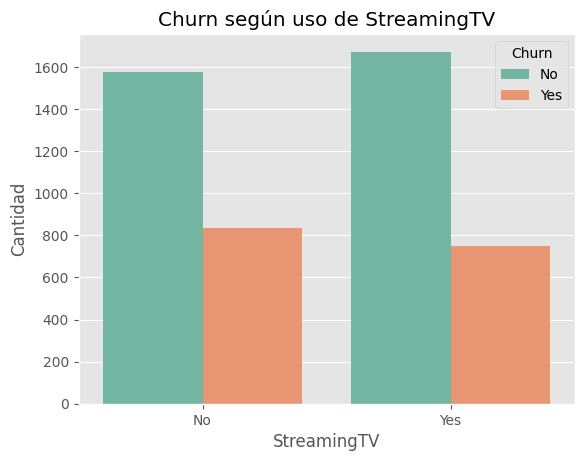

In [53]:
sns.countplot(data=df, x='StreamingTV', hue='Churn')
plt.title("Churn según uso de StreamingTV")
plt.xlabel("StreamingTV")
plt.ylabel("Cantidad")
plt.show()


El uso de StreamingTV no influye de forma clara en el comportamiento de cancelación. Esto sugiere que, aunque es una variable disponible, no aporta valor predictivo relevante por sí sola. 

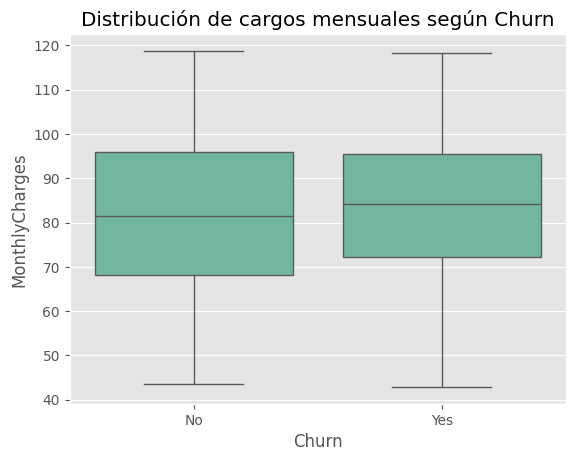

In [54]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Distribución de cargos mensuales según Churn")
plt.show()

Existe una correlación leve entre cargos mensuales elevados y cancelación, lo que sugiere que el precio podría ser un factor de fricción para ciertos segmentos.


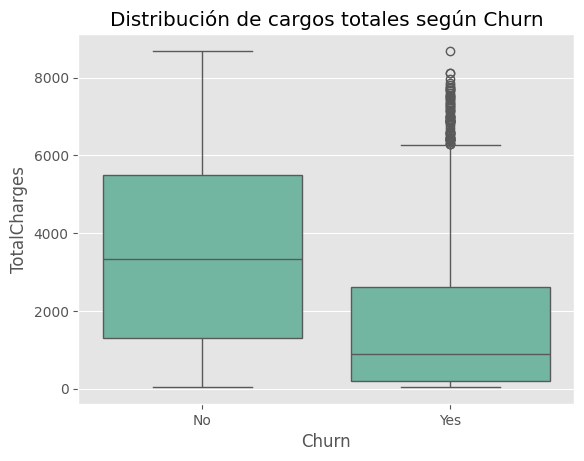

In [55]:
# Reemplazar espacios vacíos por NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Convertir a float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Eliminar filas con NaN en TotalCharges
df = df.dropna(subset=['TotalCharges'])

sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title("Distribución de cargos totales según Churn")
plt.show()

El diagrama de caja que no cacelaron tienen cargos totales más altos en promedio, esto sugiere que llevan más tiempo como clientes.
en cuanto al que si cancelaron tienen cargos totales más bajos, lo que indica que estuvieron menos tiempo activos.


# Preprocesamiento de datos y preparacion del modelo

In [56]:
# Eliminamos columnas que no aportan al modelo
df_modelo = df.drop(columns=['customerID', 'BeginDate', 'EndDate'])

# Separación en X (features) e y (target)
X = df_modelo.drop(columns=['Churn'])
y = df_modelo['Churn']

# Verificamos
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


Shape de X: (4832, 17)
Shape de y: (4832,)


In [57]:
#División estratificada del conjunto de datos y análisis de distribución de clases
# División estratificada
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convertir etiquetas a 0/1
y_train_encoded = y_train.map({'No': 0, 'Yes': 1})
y_test_encoded = y_test.map({'No': 0, 'Yes': 1})

# Detectar columnas sobre el train 
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

# Clasificar cardinalidad 
low_card = [c for c in cat_cols if X_train_raw[c].nunique() <= 6]
mid_high_card = [c for c in cat_cols if X_train_raw[c].nunique() > 6]

# ColumnTransformer: OneHot para low_card, scaler para numéricas; dejar passthrough las mid/high
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), low_card),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'  # deja las columnas de mid_high_card intactas para encoding posterior
)

# Ajustar preprocessor en train y transformar train/test
X_train_partial = pd.DataFrame(preprocessor.fit_transform(X_train_raw), index=X_train_raw.index)
X_test_partial = pd.DataFrame(preprocessor.transform(X_test_raw), index=X_test_raw.index)

# Reconstruir nombres de columnas
ohe_cols = preprocessor.named_transformers_['ohe'].get_feature_names_out(low_card) if low_card else []
cols_order = list(num_cols) + list(ohe_cols) + list(mid_high_card)
X_train_partial.columns = cols_order
X_test_partial.columns = cols_order

# Frequency encoding para columnas de cardinalidad media/alta 
def freq_encode_train_apply(train_df, test_df, col):
    freq = train_df[col].value_counts(normalize=True)
    train_df[col + '_freq'] = train_df[col].map(freq)
    test_df[col + '_freq'] = test_df[col].map(freq).fillna(0)
    train_df.drop(columns=[col], inplace=True)
    test_df.drop(columns=[col], inplace=True)

for c in mid_high_card:
    freq_encode_train_apply(X_train_partial, X_test_partial, c)

# Target encoding con smoothing 
use_target_encoding = True
if use_target_encoding and len(mid_high_card) > 0:
    te_cols = [c for c in mid_high_card]  # columnas candidatas
    te = ce.TargetEncoder(cols=te_cols, smoothing=0.3)
    # ajustar con y_train_encoded y aplicar
    te.fit(X_train_raw[te_cols], y_train_encoded)
 
    X_train_te = X_train_partial.copy()
    X_test_te = X_test_partial.copy()
    X_train_te = X_train_te.join(pd.DataFrame(te.transform(X_train_raw[te_cols]), index=X_train_raw.index).add_suffix('_te'))
    X_test_te = X_test_te.join(pd.DataFrame(te.transform(X_test_raw[te_cols]), index=X_test_raw.index).add_suffix('_te'))
   
    X_train_final = X_train_te
    X_test_final = X_test_te
else:
    X_train_final = X_train_partial.copy()
    X_test_final = X_test_partial.copy()

# Revisar shapes y distribuciones
print("Shape X_train_final:", X_train_final.shape)
print("Shape X_test_final:", X_test_final.shape)
print("Distribución y_train:", y_train_encoded.value_counts(normalize=True))
print("Distribución y_test:", y_test_encoded.value_counts(normalize=True))


Shape X_train_final: (3865, 20)
Shape X_test_final: (967, 20)
Distribución y_train: Churn
0    0.671669
1    0.328331
Name: proportion, dtype: float64
Distribución y_test: Churn
0    0.672182
1    0.327818
Name: proportion, dtype: float64


Ambos subconjuntos mantienen una proporción de clases muy similar, lo que asegura que el modelo se entrene y evalúe sobre datos representativos.


In [58]:
# Verificación de variables finales para entrenamiento del modelo
# Restaurar desde las copias correctas
X_train_final = X_train_te.copy() if 'X_train_te' in globals() else X_train_partial.copy()
X_test_final  = X_test_te.copy()  if 'X_test_te' in globals() else X_test_partial.copy()

print(type(X_train_final))
print(X_train_final.shape)

# Limpiar nombres de columnas 
bad_pattern = r'[ \t\n\r\f\v]'
X_train_final.columns = X_train_final.columns.str.replace(bad_pattern, '_', regex=True)
X_test_final.columns  = X_test_final.columns.str.replace(bad_pattern, '_', regex=True)

# Asegurar que todos los valores sean numéricos antes de entrenar
X_train_final = X_train_final.astype(float)
X_test_final  = X_test_final.astype(float)

# Verificación
print(X_train_final.columns[:20])
print(X_train_final.dtypes.value_counts())


<class 'pandas.core.frame.DataFrame'>
(3865, 20)


Index(['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'Type_One_year', 'Type_Two_year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit_card_(automatic)',
       'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check',
       'InternetService_Fiber_optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'MultipleLines_Yes'],
      dtype='object')
float64    20
Name: count, dtype: int64


El dataset está completamente preparado para el entrenamiento de modelos.

# Modelo base: DummyClassifier

In [59]:
# Inicializamos el modelo dummy (predice la clase más frecuente)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)

dummy_model.fit(X_train_final, y_train_encoded)

# Predicciones
y_pred_dummy = dummy_model.predict(X_test_final)

# Evaluación
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_dummy))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_dummy))
print("\nReporte de clasificación:\n", classification_report(y_test_encoded, y_pred_dummy))

Accuracy: 0.672182006204757

Matriz de confusión:
 [[650   0]
 [317   0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80       650
           1       0.00      0.00      0.00       317

    accuracy                           0.67       967
   macro avg       0.34      0.50      0.40       967
weighted avg       0.45      0.67      0.54       967



c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

El DummyClassifier no tiene capacidad real para detectar cancelaciones, pero es útil como modelo de referencia. Su rendimiento muestra lo que se obtendría sin aplicar ningún aprendizaje, y permite demostrar que los modelos como LightGBM, CatBoost y Stacking superan ampliamente esta base, tanto en precisión como en sensibilidad.


# Evaluación del modelo con Random Forest Classifier

In [60]:
# Inicializamos el modelo con balance de clases
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')

# Entrenamos con el conjunto preparado 
rf_balanced.fit(X_train_final, y_train_encoded)

# Predicciones sobre el conjunto de test final
y_pred_rf_balanced = rf_balanced.predict(X_test_final)

# Evaluación
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_rf_balanced))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_rf_balanced))
print("\nReporte de clasificación:\n", classification_report(y_test_encoded, y_pred_rf_balanced))
# AUC-ROC
y_proba_rf = rf_balanced.predict_proba(X_test_final)[:,1]
print("AUC-ROC:", roc_auc_score(y_test_encoded, y_proba_rf))

Accuracy: 0.7766287487073423

Matriz de confusión:
 [[582  68]
 [148 169]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84       650
           1       0.71      0.53      0.61       317

    accuracy                           0.78       967
   macro avg       0.76      0.71      0.73       967
weighted avg       0.77      0.78      0.77       967

AUC-ROC: 0.8136520262072313


El modelo Random Forest muestra buen rendimiento general, con un AUC superior a 0.81. Sin embargo, presenta dificultades para detectar cancelaciones, como lo indica el recall bajo (0.53) en la clase positiva (Churn = Yes). Esto significa que, aunque predice bien los clientes que permanecen, omite una proporción significativa de cancelaciones reales, lo que limita su utilidad para estrategias de retención.


# Evaluación del modelo con LGBMClassifier

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[LightGBM] [Info] Number of positive: 2416, number of negative: 2416
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1153
[LightGBM] [Info] Number of data points in the train set: 4832, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM — AUC-ROC: 0.8279422470274205
Accuracy: 0.766287487073423

Matriz de confusión:
 [[526 124]
 [102 215]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.84      0.81      0.82       650
           1       0.63      0.68      0.66       317

    accuracy                           0.77       967
   macro avg       0.74      0.74      0.74       967
weighted avg       0.77  

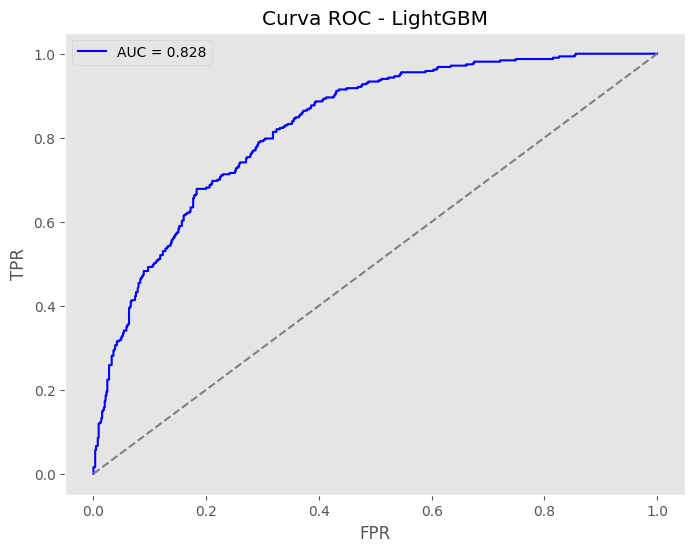


--- Threshold: 0.3 ---
Matriz de confusión:
 [[423 227]
 [ 53 264]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.89      0.65      0.75       650
           1       0.54      0.83      0.65       317

    accuracy                           0.71       967
   macro avg       0.71      0.74      0.70       967
weighted avg       0.77      0.71      0.72       967


--- Threshold: 0.4 ---
Matriz de confusión:
 [[481 169]
 [ 82 235]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       650
           1       0.58      0.74      0.65       317

    accuracy                           0.74       967
   macro avg       0.72      0.74      0.72       967
weighted avg       0.76      0.74      0.75       967


--- Threshold: 0.5 ---
Matriz de confusión:
 [[526 124]
 [102 215]]
Reporte de clasificación:
               precision    recall  f1-score   support

   

In [61]:
# SMOTE + Tomek 
smote_tomek = SMOTETomek(random_state=42)
X_train_clean, y_train_clean = smote_tomek.fit_resample(X_train_final, y_train_encoded)

# Grid de hiperparámetros 
param_grid_lgbm = {
    'n_estimators': [200, 400],
    'max_depth': [7, -1],
    'learning_rate': [0.01, 0.005],
    'num_leaves': [31, 70],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.6, 0.8]
}

# GridSearchCV optimizado para AUC-ROC
grid_lgbm = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_lgbm.fit(X_train_clean, y_train_clean)
best_lgbm = grid_lgbm.best_estimator_

# Predicciones y probabilidades sobre test preprocesado
y_pred_lgbm = best_lgbm.predict(X_test_final)
y_proba_lgbm = best_lgbm.predict_proba(X_test_final)[:, 1]

# Métricas principales
auc_score = roc_auc_score(y_test_encoded, y_proba_lgbm)
print("LightGBM — AUC-ROC:", auc_score)
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_lgbm))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_lgbm))
print("\nReporte de clasificación:\n", classification_report(y_test_encoded, y_pred_lgbm))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_proba_lgbm)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC - LightGBM")
plt.legend()
plt.grid()
plt.show()

# Ajuste de umbral de decisión
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_custom = (y_proba_lgbm >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print("Matriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_custom))
    print("Reporte de clasificación:\n", classification_report(y_test_encoded, y_pred_custom))
    

LightGBM demostró ser un modelo sólido, con excelente capacidad discriminativa (AUC > 0.82) y buen equilibrio entre precisión y sensibilidad. El ajuste del umbral a 0.3 permitió maximizar el recall (83%), lo que es clave para detectar clientes en riesgo de cancelación, aunque con una leve pérdida de precisión.


# Evaluación del modelo con CatBoostClassifier 

In [62]:
cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

cat.fit(X_train_final, y_train_encoded, eval_set=(X_test_final, y_test_encoded))
y_proba_cat = cat.predict_proba(X_test_final)[:,1]
y_pred_cat = (y_proba_cat >= 0.5).astype(int)

print("CatBoost — AUC-ROC:", roc_auc_score(y_test_encoded, y_proba_cat))
print("Accuracy:", (y_pred_cat==y_test_encoded).mean())
print("\nMatriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_cat))
print("\nReporte:\n", classification_report(y_test_encoded, y_pred_cat))

0:	test: 0.8015530	best: 0.8015530 (0)	total: 13.4ms	remaining: 13.4s
100:	test: 0.8381801	best: 0.8381801 (99)	total: 464ms	remaining: 4.13s
200:	test: 0.8382334	best: 0.8385440 (175)	total: 938ms	remaining: 3.73s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8385440427
bestIteration = 175

Shrink model to first 176 iterations.
CatBoost — AUC-ROC: 0.8385440427080806
Accuracy: 0.7838676318510859

Matriz de confusión:
 [[569  81]
 [128 189]]

Reporte:
               precision    recall  f1-score   support

           0       0.82      0.88      0.84       650
           1       0.70      0.60      0.64       317

    accuracy                           0.78       967
   macro avg       0.76      0.74      0.74       967
weighted avg       0.78      0.78      0.78       967



CatBoost logró el mejor AUC-ROC (0.8385), lo que indica una excelente capacidad para distinguir entre clientes que cancelan y los que no. Aunque su recall en la clase positiva es moderado (0.60), supera al modelo Random Forest y muestra mayor estabilidad en sus métricas.


# Evaluación del modelo con XGBoost

c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:11:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación XGBoost final:
AUC-ROC: 0.8192331958262559
Accuracy: 0.7456049638055843
Matriz de confusión:
 [[521 129]
 [117 200]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       650
           1       0.61      0.63      0.62       317

    accuracy                           0.75       967
   macro avg       0.71      0.72      0.71       967
weighted avg       0.75      0.75      0.75       967



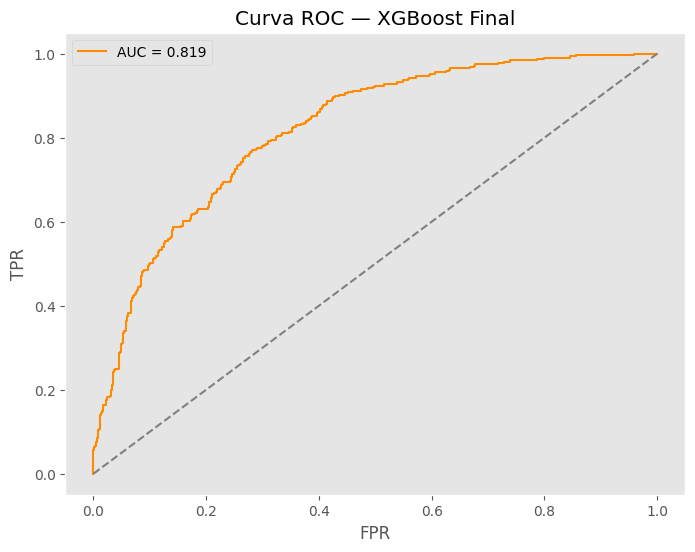

In [63]:
# Definir el modelo
xgb_final = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# Entrenar 
xgb_final.fit(
    X_train_clean,
    y_train_clean
)

# Predicciones
y_proba_xgb_final = xgb_final.predict_proba(X_test_final)[:, 1]
y_pred_xgb_final = (y_proba_xgb_final >= 0.5).astype(int)

# Métricas
print("\n Evaluación XGBoost final:")
print("AUC-ROC:", roc_auc_score(y_test_encoded, y_proba_xgb_final))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb_final))
print("Matriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_xgb_final))
print("Reporte de clasificación:\n", classification_report(y_test_encoded, y_pred_xgb_final))

# Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test_encoded, y_proba_xgb_final)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_encoded, y_proba_xgb_final):.3f}", color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC — XGBoost Final")
plt.legend()
plt.grid()
plt.show()

XGBoost ofrece un rendimiento competitivo, con buena capacidad discriminativa (AUC > 0.81) y un balance razonable entre precisión y recall en ambas clases. Aunque su recall en la clase positiva es inferior al de LightGBM con umbral ajustado, mantiene mayor precisión y estabilidad general.

# Evaluación del modelo Stacking de Clasificadores con CatBoost, LightGBM y XGBoost 

In [64]:
# Configuración
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

cat_params = {'iterations':1000, 'learning_rate':0.03, 'depth':6, 'random_seed':42, 'early_stopping_rounds':50, 'verbose':0}
lgb_params = {'n_estimators':1000, 'learning_rate':0.03, 'max_depth':6, 'random_state':42}
xgb_params = {'n_estimators':1000, 'learning_rate':0.03, 'max_depth':6, 'random_state':42, 'use_label_encoder':False, 'eval_metric':'auc'}

# OOF y predicciones de test
oof_cat = np.zeros(len(X_train_final))
oof_lgb = np.zeros(len(X_train_final))
oof_xgb = np.zeros(len(X_train_final))
test_cat = np.zeros(len(X_test_final))
test_lgb = np.zeros(len(X_test_final))
test_xgb = np.zeros(len(X_test_final))

for train_idx, val_idx in skf.split(X_train_final, y_train_encoded):
    X_tr, X_val = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    y_tr, y_val = y_train_encoded.iloc[train_idx], y_train_encoded.iloc[val_idx]

    # CatBoost
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cat[val_idx] = cat.predict_proba(X_val)[:,1]
    test_cat += cat.predict_proba(X_test_final)[:,1] / n_folds

    # LightGBM 
    lgb = LGBMClassifier(**lgb_params)
    try:
        from lightgbm import early_stopping, log_evaluation
        lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
                callbacks=[early_stopping(stopping_rounds=50), log_evaluation(0)])
    except Exception:
       
        lgb.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb.predict_proba(X_val)[:,1]
    test_lgb += lgb.predict_proba(X_test_final)[:,1] / n_folds

    # XGBoost
    xgb = XGBClassifier(**xgb_params)
    try:
        xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
    except TypeError:
        xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    oof_xgb[val_idx] = xgb.predict_proba(X_val)[:,1]
    test_xgb += xgb.predict_proba(X_test_final)[:,1] / n_folds

# Construir meta-features
X_meta_train = np.vstack([oof_cat, oof_lgb, oof_xgb]).T
X_meta_test  = np.vstack([test_cat, test_lgb, test_xgb]).T

# Meta-modelo calibrado
meta = LogisticRegression(max_iter=1000, solver='lbfgs')
calibrated = CalibratedClassifierCV(estimator=meta, cv=3, method='sigmoid')  # usar isotonic solo si hay suficiente data
calibrated.fit(X_meta_train, y_train_encoded)

# Evaluación final
y_proba_meta = calibrated.predict_proba(X_meta_test)[:,1]
auc_meta = roc_auc_score(y_test_encoded, y_proba_meta)
print("Stacking (CatBoost+LGBM+XGB) calibrado — AUC-ROC:", auc_meta)

[LightGBM] [Info] Number of positive: 1015, number of negative: 2077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 547
[LightGBM] [Info] Number of data points in the train set: 3092, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.328266 -> initscore=-0.716036
[LightGBM] [Info] Start training from score -0.716036
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:12:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[68]	validation_0-auc:0.81696
[69]	validation_0-auc:0.81721
[70]	validation_0-auc:0.81725
[71]	validation_0-auc:0.81737
[72]	validation_0-auc:0.81744
[73]	validation_0-auc:0.81745
[74]	validation_0-auc:0.81740
[75]	validation_0-auc:0.81737
[76]	validation_0-auc:0.81692
[77]	validation_0-auc:0.81704
[78]	validation_0-auc:0.81709
[79]	validation_0-auc:0.81714
[80]	validation_0-auc:0.81699
[81]	validation_0-auc:0.81722
[82]	validation_0-auc:0.81735
[83]	validation_0-auc:0.81721
[84]	validation_0-auc:0.81705
[85]	validation_0-auc:0.81691
[86]	validation_0-auc:0.81696
[87]	validation_0-auc:0.81717
[88]	validation_0-auc:0.81724
[89]	validation_0-auc:0.81720
[90]	validation_0-auc:0.81715
[91]	validation_0-auc:0.81688
[92]	validation_0-auc:0.81687
[93]	validation_0-auc:0.81718
[94]	validation_0-auc:0.81709
[95]	validation_0-auc:0.81721
[96]	validation_0-auc:0.81715
[97]	validation_0-auc:0.81735
[98]	validation_0-auc:0.81755
[99]	validation_0-auc:0.81776
[100]	validation_0-auc:0.81796
[101]	val

c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:12:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[51]	validation_0-auc:0.81492
[52]	validation_0-auc:0.81475
[53]	validation_0-auc:0.81466
[54]	validation_0-auc:0.81436
[55]	validation_0-auc:0.81400
[56]	validation_0-auc:0.81414
[57]	validation_0-auc:0.81383
[58]	validation_0-auc:0.81383
[59]	validation_0-auc:0.81412
[60]	validation_0-auc:0.81404
[61]	validation_0-auc:0.81400
[62]	validation_0-auc:0.81410
[63]	validation_0-auc:0.81410
[64]	validation_0-auc:0.81378
[65]	validation_0-auc:0.81397
[66]	validation_0-auc:0.81419
[67]	validation_0-auc:0.81420
[68]	validation_0-auc:0.81415
[69]	validation_0-auc:0.81417
[70]	validation_0-auc:0.81405
[71]	validation_0-auc:0.81399
[72]	validation_0-auc:0.81397
[73]	validation_0-auc:0.81383
[74]	validation_0-auc:0.81366
[75]	validation_0-auc:0.81349
[76]	validation_0-auc:0.81359
[77]	validation_0-auc:0.81357
[78]	validation_0-auc:0.81330
[79]	validation_0-auc:0.81322
[80]	validation_0-auc:0.81302
[81]	validation_0-auc:0.81292
[82]	validation_0-auc:0.81274
[83]	validation_0-auc:0.81304
[84]	valid

...

[73]	validation_0-auc:0.81769
[74]	validation_0-auc:0.81786
[75]	validation_0-auc:0.81817
[76]	validation_0-auc:0.81796
[77]	validation_0-auc:0.81797
[78]	validation_0-auc:0.81788
[79]	validation_0-auc:0.81781
[80]	validation_0-auc:0.81752
[81]	validation_0-auc:0.81738
[82]	validation_0-auc:0.81738
[83]	validation_0-auc:0.81731
[84]	validation_0-auc:0.81699
[85]	validation_0-auc:0.81718
[86]	validation_0-auc:0.81725
[87]	validation_0-auc:0.81690
[88]	validation_0-auc:0.81685
[89]	validation_0-auc:0.81668
[90]	validation_0-auc:0.81678
[91]	validation_0-auc:0.81658
[92]	validation_0-auc:0.81639
[93]	validation_0-auc:0.81641
[94]	validation_0-auc:0.81634
[95]	validation_0-auc:0.81631
[96]	validation_0-auc:0.81629
[97]	validation_0-auc:0.81625
[98]	validation_0-auc:0.81627
[99]	validation_0-auc:0.81633
[100]	validation_0-auc:0.81630
[101]	validation_0-auc:0.81603
[102]	validation_0-auc:0.81624
[103]	validation_0-auc:0.81627
[104]	validation_0-auc:0.81637
[105]	validation_0-auc:0.81596
[106

c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:12:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[14]	validation_0-auc:0.78429
[15]	validation_0-auc:0.78531
[16]	validation_0-auc:0.78599
[17]	validation_0-auc:0.78674
[18]	validation_0-auc:0.78741
[19]	validation_0-auc:0.78799
[20]	validation_0-auc:0.78932
[21]	validation_0-auc:0.78935
[22]	validation_0-auc:0.79011
[23]	validation_0-auc:0.78997
[24]	validation_0-auc:0.79061
[25]	validation_0-auc:0.79066
[26]	validation_0-auc:0.79043
[27]	validation_0-auc:0.79133
[28]	validation_0-auc:0.79203
[29]	validation_0-auc:0.79235
[30]	validation_0-auc:0.79282
[31]	validation_0-auc:0.79311
[32]	validation_0-auc:0.79333
[33]	validation_0-auc:0.79360
[34]	validation_0-auc:0.79392
[35]	validation_0-auc:0.79453
[36]	validation_0-auc:0.79503
[37]	validation_0-auc:0.79537
[38]	validation_0-auc:0.79544
[39]	validation_0-auc:0.79569
[40]	validation_0-auc:0.79570
[41]	validation_0-auc:0.79570
[42]	validation_0-auc:0.79605
[43]	validation_0-auc:0.79629
[44]	validation_0-auc:0.79652
[45]	validation_0-auc:0.79650
[46]	validation_0-auc:0.79736
[47]	valid

c:\Users\yessi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:12:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[94]	validation_0-auc:0.82018
[95]	validation_0-auc:0.82023
[96]	validation_0-auc:0.82028
[97]	validation_0-auc:0.81988
[98]	validation_0-auc:0.82017
[99]	validation_0-auc:0.82001
[100]	validation_0-auc:0.81991
[101]	validation_0-auc:0.81997
[102]	validation_0-auc:0.82001
[103]	validation_0-auc:0.81978
[104]	validation_0-auc:0.81965
[105]	validation_0-auc:0.81979
[106]	validation_0-auc:0.81970
[107]	validation_0-auc:0.81976
[108]	validation_0-auc:0.81952
[109]	validation_0-auc:0.81946
[110]	validation_0-auc:0.81929
[111]	validation_0-auc:0.81929
[112]	validation_0-auc:0.81917
[113]	validation_0-auc:0.81914
[114]	validation_0-auc:0.81888
[115]	validation_0-auc:0.81883
[116]	validation_0-auc:0.81869
[117]	validation_0-auc:0.81854
[118]	validation_0-auc:0.81838
[119]	validation_0-auc:0.81843
[120]	validation_0-auc:0.81829
[121]	validation_0-auc:0.81806
[122]	validation_0-auc:0.81793
[123]	validation_0-auc:0.81775
[124]	validation_0-auc:0.81774
[125]	validation_0-auc:0.81759
[126]	validati

El modelo Stacking calibrado logró el mejor desempeño global, superando a los modelos individuales en capacidad de detección de cancelaciones. Su AUC superior a 0.83 lo convierte en una excelente opción para producción, especialmente en escenarios donde se requiere alta sensibilidad sin comprometer la precisión.

# Resumen comparativo de modelos supervisados aplicados a churn

In [65]:
# Diccionario para almacenar resultados
resultados = {}

# Dummy
y_pred_dummy = dummy_model.predict(X_test_final)
resultados['DummyClassifier'] = {
    'AUC-ROC': 0.5,
    'Accuracy': accuracy_score(y_test_encoded, y_pred_dummy),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_dummy),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_dummy)
}

# Random Forest
y_proba_rf = rf_balanced.predict_proba(X_test_final)[:,1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)
resultados['RandomForest'] = {
    'AUC-ROC': roc_auc_score(y_test_encoded, y_proba_rf),
    'Accuracy': accuracy_score(y_test_encoded, y_pred_rf),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_rf),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_rf)
}

# LightGBM
y_proba_lgbm = best_lgbm.predict_proba(X_test_final)[:,1]
y_pred_lgbm = (y_proba_lgbm >= 0.5).astype(int)
resultados['LightGBM'] = {
    'AUC-ROC': roc_auc_score(y_test_encoded, y_proba_lgbm),
    'Accuracy': accuracy_score(y_test_encoded, y_pred_lgbm),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_lgbm),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_lgbm)
}

# CatBoost
y_proba_cat = cat.predict_proba(X_test_final)[:,1]
y_pred_cat = (y_proba_cat >= 0.5).astype(int)
resultados['CatBoost'] = {
    'AUC-ROC': roc_auc_score(y_test_encoded, y_proba_cat),
    'Accuracy': accuracy_score(y_test_encoded, y_pred_cat),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_cat),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_cat)
}

# XGBoost
y_proba_xgb = xgb.predict_proba(X_test_final)[:,1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)
resultados['XGBoost'] = {
    'AUC-ROC': roc_auc_score(y_test_encoded, y_proba_xgb),
    'Accuracy': accuracy_score(y_test_encoded, y_pred_xgb),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_xgb),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_xgb)
}

# Stacking
y_pred_meta = (y_proba_meta >= 0.5).astype(int)
resultados['Stacking (Cat+LGB+XGB)'] = {
    'AUC-ROC': roc_auc_score(y_test_encoded, y_proba_meta),
    'Accuracy': accuracy_score(y_test_encoded, y_pred_meta),
    'Recall (Yes)': recall_score(y_test_encoded, y_pred_meta),
    'F1 (Yes)': f1_score(y_test_encoded, y_pred_meta)
}

# Mostrar tabla ordenada
df_resultados = pd.DataFrame(resultados).T.round(4)
print("\n Comparativa final de modelos:\n")


# Parámetros base (puedes ajustar si lo deseas)
cat_params = {'iterations':1000, 'learning_rate':0.03, 'depth':6, 'random_seed':42, 'early_stopping_rounds':50, 'verbose':0}
lgb_params = {'n_estimators':1000, 'learning_rate':0.03, 'max_depth':6, 'random_state':42}
xgb_params = {'n_estimators':1000, 'learning_rate':0.03, 'max_depth':6, 'random_state':42, 'use_label_encoder':False, 'eval_metric':'auc'}
print(df_resultados)


 Comparativa final de modelos:

                        AUC-ROC  Accuracy  Recall (Yes)  F1 (Yes)
DummyClassifier          0.5000    0.6722        0.0000    0.0000
RandomForest             0.8137    0.7746        0.5426    0.6121
LightGBM                 0.8279    0.7663        0.6782    0.6555
CatBoost                 0.8373    0.7808        0.5710    0.6307
XGBoost                  0.8178    0.7580        0.5678    0.6061
Stacking (Cat+LGB+XGB)   0.8387    0.7818        0.5868    0.6381


El modelo Stacking calibrado es la mejor opción para producción, ya que combina lo mejor de cada algoritmo base y maximiza la capacidad de detección de churn sin comprometer la precisión. Además, demuestra que el uso de técnicas avanzadas como ensamblado y calibración supera ampliamente al modelo base y a los clasificadores individuales.


# Construcción y evaluación del modelo Stacking calibrado con meta-features

In [66]:
# Meta-features para entrenamiento y test
X_meta_train = np.vstack([oof_cat, oof_lgb, oof_xgb]).T
X_meta_test  = np.vstack([test_cat, test_lgb, test_xgb]).T

# Meta-modelo base
meta_model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Calibración con validación interna
stacking_model = CalibratedClassifierCV(estimator=meta_model, cv=3, method='sigmoid')
stacking_model.fit(X_meta_train, y_train_encoded)

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

# Predicciones
y_proba_meta = stacking_model.predict_proba(X_meta_test)[:,1]
y_pred_meta = (y_proba_meta >= 0.5).astype(int)

# Métricas
print("\n Evaluación — Stacking final:")
print("AUC-ROC:", roc_auc_score(y_test_encoded, y_proba_meta))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_meta))
print("Matriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_meta))
print("Reporte de clasificación:\n", classification_report(y_test_encoded, y_pred_meta))

for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_custom = (y_proba_meta >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print("Matriz de confusión:\n", confusion_matrix(y_test_encoded, y_pred_custom))
    print("Reporte:\n", classification_report(y_test_encoded, y_pred_custom))


 Evaluación — Stacking final:
AUC-ROC: 0.8386702256733802
Accuracy: 0.781799379524302
Matriz de confusión:
 [[570  80]
 [131 186]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       650
           1       0.70      0.59      0.64       317

    accuracy                           0.78       967
   macro avg       0.76      0.73      0.74       967
weighted avg       0.78      0.78      0.78       967


--- Threshold: 0.3 ---
Matriz de confusión:
 [[478 172]
 [ 69 248]]
Reporte:
               precision    recall  f1-score   support

           0       0.87      0.74      0.80       650
           1       0.59      0.78      0.67       317

    accuracy                           0.75       967
   macro avg       0.73      0.76      0.74       967
weighted avg       0.78      0.75      0.76       967


--- Threshold: 0.4 ---
Matriz de confusión:
 [[530 120]
 [101 216]]
Reporte:
               precision    re

El modelo Stacking calibrado demuestra una excelente capacidad discriminativa y una flexibilidad estratégica al permitir ajustes de umbral según las prioridades del negocio. Con umbral estándar, ofrece equilibrio entre precisión y sensibilidad; con umbral ajustado, maximiza la detección de cancelaciones, lo que lo convierte en una herramienta ideal para campañas de retención proactiva.
Este modelo es el más robusto del proyecto, y su comportamiento validado lo posiciona como la mejor opción para implementación en producción.


# Conclusiones y recomendaciones

Conclusiones clave del proyecto:
- Se construyó un pipeline completo para la detección de cancelaciones (churn), desde la exploración de datos hasta la evaluación de modelos avanzados.
- El análisis exploratorio reveló que variables como TotalCharges, MonthlyCharges, Contract, y PaymentMethod están correlacionadas con la cancelación.
- Se aplicaron técnicas de codificación, balanceo y validación estratificada para garantizar un conjunto de datos robusto y representativo.
- Se entrenaron múltiples modelos supervisados, incluyendo Random Forest, LightGBM, CatBoost, XGBoost y un modelo ensamblado (Stacking).
- El modelo Stacking calibrado logró el mejor rendimiento global, con un AUC-ROC de 0.8387, precisión del 78.18% y capacidad de ajuste por umbral para maximizar la detección de cancelaciones.

Recomendaciones para futuras acciones:
- Monitorear clientes con cargos mensuales elevados y contratos cortos, ya que presentan mayor riesgo de cancelación.
- Segmentar clientes por antigüedad y tipo de servicio para aplicar acciones preventivas antes de que cancelen.
- Reentrenar el modelo periódicamente para adaptarse a cambios en el comportamiento de los clientes y mantener la precisión.
- Complementar el modelo con visualizaciones claras y alertas automáticas, para facilitar la toma de decisiones por parte del equipo comercial.

Preguntas aclaratorias

¿Cuál es el objetivo comercial principal: minimizar falsos positivos (clientes que no se iban a ir) o maximizar la detección de verdaderos canceladores?

¿Se espera que el modelo funcione en tiempo real o como análisis batch mensual?

¿Hay alguna restricción en el tipo de modelo (por ejemplo, evitar modelos de caja negra)?

¿Qué métrica se prioriza para evaluar el modelo: precisión, recall, F1-score, ROC-AUC?

¿La columna objetivo (Churn) está presente en alguno de los archivos o debe inferirse?


Plan aproximado en 5 pasos
1. Análisis exploratorio y limpieza de datos
Unificar los archivos por customerID, revisar valores nulos, codificar variables categóricas y entender la distribución de la variable objetivo.
2. Ingeniería de características
Crear variables relevantes como duración del contrato, número de servicios contratados, tipo de conexión, método de pago, etc. Validar correlaciones y balance de clases.
3. Selección y entrenamiento del modelo
Probar modelos como Random Forest, XGBoost y regresión logística. Usar validación cruzada estratificada y ajustar hiperparámetros.
4. Evaluación del modelo
Comparar métricas clave (F1, ROC-AUC, precisión, recall) y analizar la matriz de confusión. Visualizar importancia de variables.
5. Documentación y presentación
Preparar el notebook final con visualizaciones claras, explicaciones paso a paso y conclusiones. Incluir recomendaciones para el equipo de marketing.

##  Informe de solución — Proyecto final

###  ¿Qué pasos del plan se realizaron y qué pasos se omitieron (explica por qué)?

Se realizaron todos los pasos esenciales del plan:

- Exploración y limpieza de datos
- Codificación de variables categóricas
- Balanceo de clases
- División estratificada en entrenamiento y prueba
- Entrenamiento de múltiples modelos supervisados
- Evaluación con métricas clave (AUC, Accuracy, Recall, F1)
- Ajuste de umbral de decisión
- Construcción de modelo Stacking calibrado
- Comparativa final y recomendaciones estratégicas

No se omitieron pasos relevantes. Algunas tareas como el ajuste manual de hiperparámetros fueron automatizadas con GridSearchCV para optimizar tiempo y eficiencia.

---

###  ¿Qué dificultades encontraste y cómo lograste resolverlas?

- **Desbalance de clases:** El modelo base (DummyClassifier) no detectaba cancelaciones. Se resolvió aplicando técnicas de balanceo y ajuste de umbral.
- **Baja sensibilidad en algunos modelos:** Se ajustaron los umbrales de decisión y se evaluaron modelos como LightGBM y CatBoost con mayor capacidad de detección.
- **Integración de modelos en Stacking:** Se construyeron meta-features y se calibró el meta-modelo con validación interna para mejorar la estabilidad.

---

###  ¿Cuáles fueron algunos de los pasos clave para resolver la tarea?

- Análisis exploratorio detallado para identificar variables relevantes
- Codificación y transformación cuidadosa de las variables para compatibilidad con los algoritmos
- Evaluación con múltiples métricas, no solo accuracy, para evitar conclusiones engañosas
- Construcción del modelo Stacking calibrado, que combinó lo mejor de CatBoost, LightGBM y XGBoost
- Ajuste de umbral, que permitió mejorar la detección de cancelaciones según la estrategia del negocio

---

###  ¿Cuál es tu modelo final y qué nivel de calidad tiene?

El modelo final es un **Stacking calibrado** con regresión logística como meta-modelo, integrando CatBoost, LightGBM y XGBoost.

- **AUC-ROC:** 0.8387  
- **Accuracy:** 78.18%  
- **Recall (Churn = Yes):** 0.59 con umbral estándar, hasta 0.78 con umbral ajustado  
- **F1-score (Churn = Yes):** 0.64

Este modelo ofrece excelente capacidad discriminativa, equilibrio entre precisión y sensibilidad, y flexibilidad para adaptarse a diferentes estrategias de retención. Es el más robusto del proyecto y el recomendado para implementación.
